In [48]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df['job_type_skills'] = df['job_type_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else {})

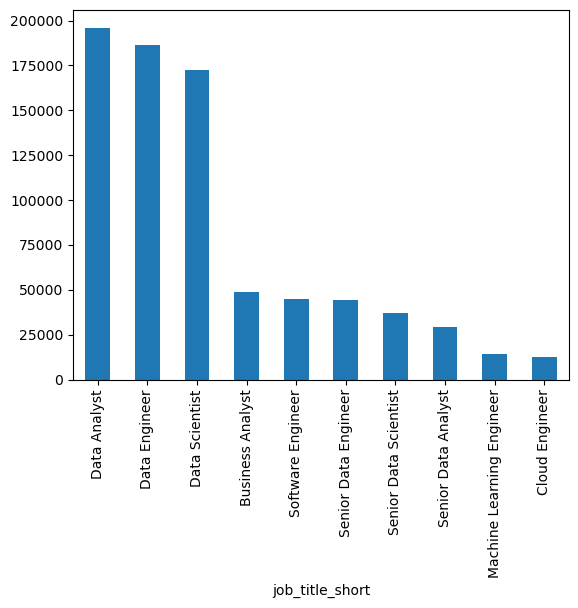

In [49]:
# create a simple subplot
#pd.options.plotting.backend = "matplotlib"
fig, ax = plt.subplots()

# plot the data
df['job_title_short'].value_counts().plot(kind='bar', ax=ax)
plt.show()

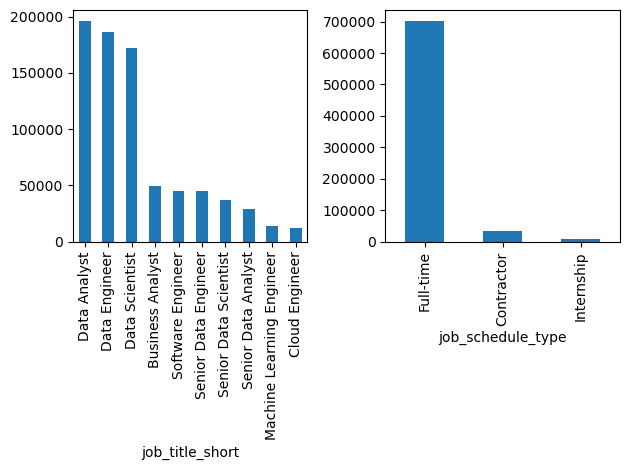

In [50]:
fig, ax = plt.subplots(1, 2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax[1])
plt.tight_layout()
plt.show()

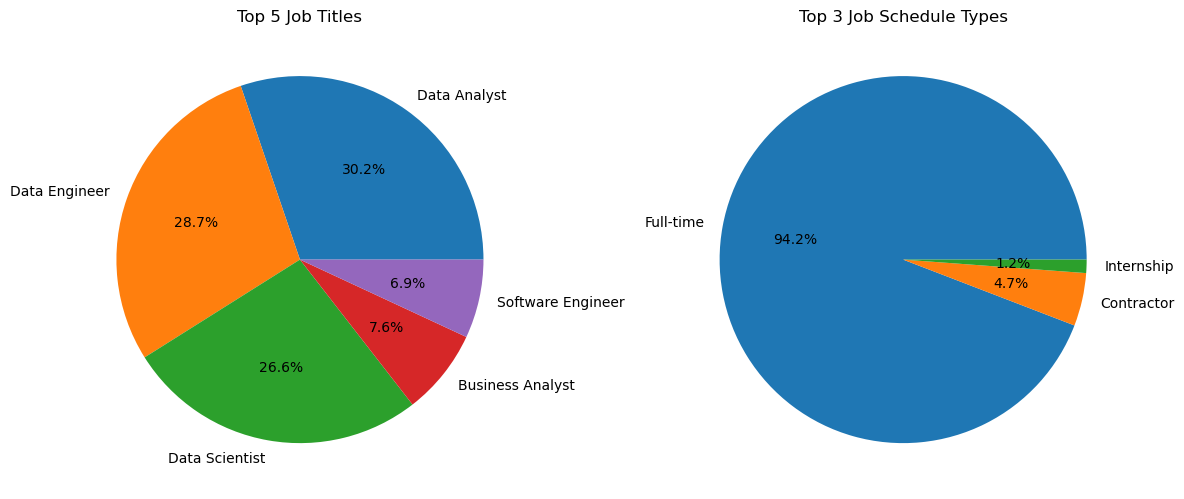

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].pie(df['job_title_short'].value_counts().head(5), labels=df['job_title_short'].value_counts().head(5).index, autopct='%1.1f%%')
ax[0].set_title('Top 5 Job Titles')

ax[1].pie(df['job_schedule_type'].value_counts().head(3), labels=df['job_schedule_type'].value_counts().head(3).index, autopct='%1.1f%%')
ax[1].set_title('Top 3 Job Schedule Types')

plt.tight_layout()
plt.show()

In [53]:
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
# count the skills
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
skills_count = skills_count.reset_index(name='skill_count')
skills_count = skills_count.sort_values(by='skill_count', ascending=False)
skills_count.head(10)

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
558,excel,Data Analyst,66860
141,aws,Data Engineer,62049
151,azure,Data Engineer,60674
1518,r,Data Scientist,59566
1478,python,Data Analyst,57190


In [ ]:
# get the top 3 job titles
top_3_jobs = skills_count['job_title_short'].value_counts().head(3).index.to_list()
top_3_jobs

['Data Engineer', 'Software Engineer', 'Data Scientist']

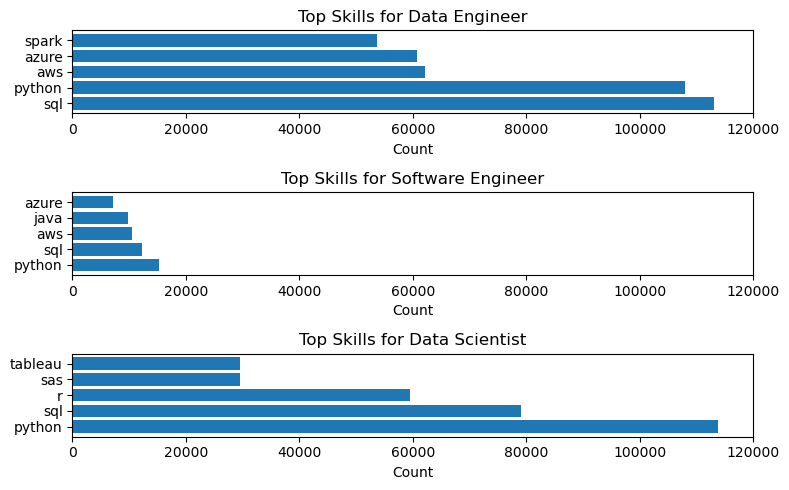

In [ ]:
# plot these jobs on the same plot
fig, ax = plt.subplots(len(top_3_jobs), 1, figsize=(8, 5))

for i, job in enumerate(top_3_jobs):
    df_plot = skills_count[skills_count['job_title_short'] == job].head(5)
    ax[i].barh(df_plot['job_skills'], df_plot['skill_count'])
    ax[i].set_title(f'Top Skills for {job}')
    ax[i].set_xlabel('Count')
    #ax[i].set_ylabel('Skills')
    ax[i].set_xlim(0, 120000) # make the scales the same
plt.tight_layout()
plt.show()

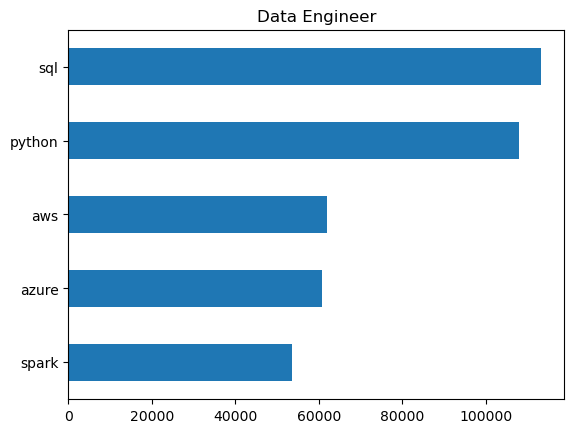

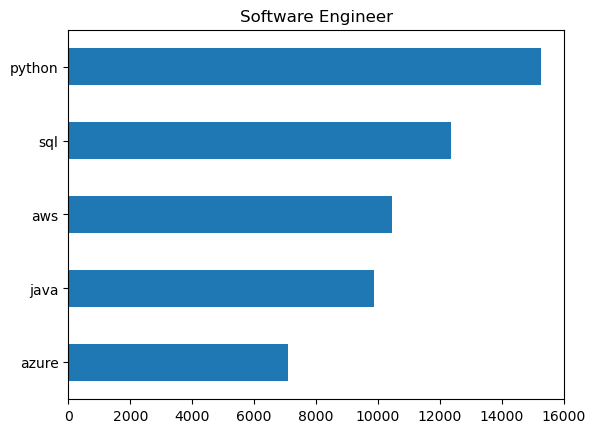

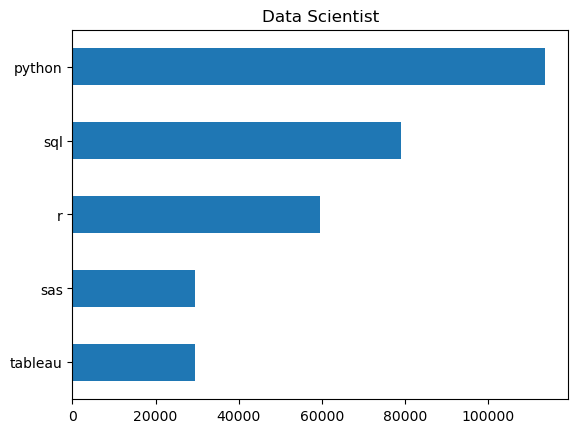

In [ ]:
for i, job_title in enumerate(top_3_jobs):
    skills_count[skills_count['job_title_short'] == job_title].head(5).plot(kind='barh', x='job_skills', y='skill_count', title=job_title)
    plt.gca().invert_yaxis()
    plt.gca().set_ylabel('')
    plt.gca().get_legend().remove()
    plt.show()

In [ ]:
plt.savefig('top_skills.png')

plt.show()

<Figure size 640x480 with 0 Axes>